# Parameter Biases from Model Mismatches

In this notebook, we will recreate the ACT DR4 beam leakage plot (Figure 14 from https://arxiv.org/pdf/2007.07288) using the DR6 data.

We can do this efficiently by rapidly estimating Fisher matrices and projecting them into parameter spaces. We note that, if two models A and B differ in observed bandpowers by some $\Delta D_\ell$, then their parameters $\theta$ will differ by

$$
    \Delta \theta = F^{-1} \frac{\partial D_\ell}{\partial \theta} \Sigma^{-1} \Delta D_\ell
$$

where $F^{-1}$ is the inverse Fisher matrix, $\frac{\partial D_\ell}{\partial \theta}$ is the derivative of the model, and $\Sigma$ is the covariance matrix of the likelihood.

In [1]:
import jax
from jax import numpy as jnp
from jax import scipy as jsc
from jax import random as jrd

import numpy as np
import matplotlib.pyplot as plt

import camb

import sys
sys.path.insert(0, "../")

import mflike_jax
import mflike_jax.util

import pprint

try:
    from tqdm.notebook import tqdm
except:
    tqdm = lambda x: x

/home/ojima/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [8]:
import sys

sys.path.insert(0, "cosmopower")

import cosmopower as cp
from cosmopower_jax.cosmopower_jax import CosmoPowerJAX

parser = cp.YAMLParser("jense_2024_emulators/jense_2023_cmb_camb_lcdm.yaml", root_dir="jense_2024_emulators")

emulators = mflike_jax.util.emulators_to_jax(parser)

cmb_tt = emulators["tt"]
cmb_te = emulators["te"]
cmb_ee = emulators["ee"]

T_CMB = 2.72548e6

Failed to restore network derived: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_derived:  does not exist..
Failed to restore network Hubble: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_Hubble:  does not exist..
Failed to restore network angular_diameter_distance: Failed to restore network from jense_2024_emulators/jense_2023_camb_lcdm/networks/jense_2023_camb_lcdm_angular_diameter_distance:  does not exist..


In [9]:
like = mflike_jax.MFLike_jax("../act_dr6.yaml")
fg_model = mflike_jax.BandpowerForegrounds("../act_dr6_foregrounds.yaml", like)

priors = {
    "calG_all": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.003),

    "cal_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.013),
    "cal_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0016),
    "cal_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0020),
    "cal_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0018),
    "cal_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=1.0, scale=0.0024),

    "bandint_shift_dr6_pa4_f220": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=3.6),
    "bandint_shift_dr6_pa5_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.0),
    "bandint_shift_dr6_pa5_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.3),
    "bandint_shift_dr6_pa6_f090": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.2),
    "bandint_shift_dr6_pa6_f150": lambda x: jsc.stats.norm.logpdf(x, loc=0.0, scale=1.1),

    "a_gtt": lambda x: jsc.stats.norm.logpdf(x, loc=7.95, scale=0.32),
    "a_gte": lambda x: jsc.stats.norm.logpdf(x, loc=0.432, scale=0.03),
    "a_gee": lambda x: jsc.stats.norm.logpdf(x, loc=0.1681, scale=0.017),

    "tau": lambda x: jsc.stats.norm.logpdf(x, loc=5.44e-2, scale=7e-3),
}

parameters = cmb_tt.parameters + like.parameters + fg_model.parameters

cmb_idx = jnp.array([ parameters.index(p) for p in cmb_tt.parameters ])
like_idx = jnp.array([ parameters.index(p) for p in like.parameters ])
fg_idx = jnp.array([ parameters.index(p) for p in fg_model.parameters ])

@jax.jit
def cmb_spectra(theta):
    spec_tt = jnp.concatenate([ jnp.array([0.,0.]), cmb_tt.predict(theta) * (T_CMB ** 2.) ])
    spec_te = jnp.concatenate([ jnp.array([0.,0.]), cmb_te.predict(theta) * (T_CMB ** 2.) ])
    spec_ee = jnp.concatenate([ jnp.array([0.,0.]), cmb_ee.predict(theta) * (T_CMB ** 2.) ])

    return spec_tt, spec_te, spec_ee

@jax.jit
def get_model(theta):
    fit_idx = jnp.array([ parameters.index(p) for p in parameters_baseline ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    theta = theta_default.at[fit_idx].set(theta)
    
    theta_cmb = theta[cmb_idx]
    theta_like = theta[like_idx]
    theta_fg = theta[fg_idx]

    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    return like.get_model(dltt, dlte, dlee, foregrounds, theta_like)

@jax.jit
def logpost(theta):
    fit_idx = jnp.array([ parameters.index(p) for p in parameters_baseline ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    theta = theta_default.at[fit_idx].set(theta)
    
    logprior = jnp.sum(jnp.array([
        priors[p](theta[parameters.index(p)]) for p in priors
    ]))

    theta_cmb = theta[cmb_idx]
    theta_like = theta[like_idx]
    theta_fg = theta[fg_idx]

    cl_tt, cl_te, cl_ee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    loglike = -0.5 * like.chisquare(cl_tt, cl_te, cl_ee, foregrounds, theta_like)

    return logprior + loglike

Assuming data rows are in the correct order as it was before version 1.0.


In [10]:
parameter_values = {
    "ombh2": 0.022,
    "omch2": 0.117,
    "h": 0.67,
    "logA": 3.05,
    "ns": 0.97,
    "tau": 0.06,

    "a_tSZ": 3.4,
    "alpha_tSZ": -0.5,
    "a_kSZ": 1.5,
    "a_c": 3.7,
    "a_p": 7.7,
    "beta_cib": 1.9,
    "xi": 0.1,
    "a_s": 2.8,
    "beta_s": -2.8,
    "a_pste": -0.025,
    "a_psee": 0.02,

    "a_gtt": 7.95,
    "a_gte": 0.423,
    "a_gee": 0.1681,

    "alpha_dT": -0.6,
    "alpha_dE": -0.4,
    "alpha_s": 1.0,
    "T_effd": 19.6,
    "T_d": 9.7,
    "beta_d": 1.5,
    "alpha_p": 1.0,
    "alpha_c": 0.8,

    "calG_all": 1.0,

    "cal_dr6_pa4_f220": 1.0,
    "cal_dr6_pa5_f090": 1.0,
    "cal_dr6_pa5_f150": 1.0,
    "cal_dr6_pa6_f090": 1.0,
    "cal_dr6_pa6_f150": 1.0,

    "calE_dr6_pa4_f220": 1.0,
    "calE_dr6_pa5_f090": 1.0,
    "calE_dr6_pa5_f150": 1.0,
    "calE_dr6_pa6_f090": 1.0,
    "calE_dr6_pa6_f150": 1.0,

    "bandint_shift_dr6_pa4_f220": 0.0,
    "bandint_shift_dr6_pa5_f090": 0.0,
    "bandint_shift_dr6_pa5_f150": 0.0,
    "bandint_shift_dr6_pa6_f090": 0.0,
    "bandint_shift_dr6_pa6_f150": 0.0,
}

parameters_baseline = [
    "ombh2", "omch2", "h", "logA", "tau", "ns",
    "a_tSZ", "a_kSZ", "alpha_tSZ", "xi", "a_c", "a_p", "beta_cib", "a_s", "beta_s",
    "a_gtt", "a_gte", "a_gee", "a_pste", "a_psee",
    "calG_all", "cal_dr6_pa4_f220", "cal_dr6_pa5_f090", "cal_dr6_pa5_f150", "cal_dr6_pa6_f090", "cal_dr6_pa6_f150",
    "calE_dr6_pa5_f090", "calE_dr6_pa5_f150", "calE_dr6_pa6_f090", "calE_dr6_pa6_f150",
    "bandint_shift_dr6_pa4_f220", "bandint_shift_dr6_pa5_f090", "bandint_shift_dr6_pa5_f150", "bandint_shift_dr6_pa6_f090", "bandint_shift_dr6_pa6_f150",
]

theta_baseline = jnp.array([parameter_values[p] for p in parameters_baseline])

print(f"log-post = {logpost(theta_baseline)}")

log-post = -1354.3487548828125


In [11]:
jac_cmb = jax.jit(jax.jacfwd(get_model))

In [12]:
J = jac_cmb(theta_baseline)

In [14]:
F = J.T @ like.inv_cov @ J

In [21]:
cov = jnp.linalg.inv(F)
err = np.sqrt(np.diag(cov))

In [17]:
import matplotlib.patches as mpt
import matplotlib.transforms as mtr

def add_ellipse(ax, m, s, cov, nstd=1., **kwargs):
    R = cov / (s[0] * s[1])
    erx = np.sqrt(1. + R)
    ery = np.sqrt(1. - R)

    ell = mpt.Ellipse((0, 0), width=2*erx, height=2*ery, **kwargs)
    mx, my = m
    sx, sy = s

    tf = mtr.Affine2D().rotate_deg(45).scale(nstd*sx, nstd*sy).translate(mx, my)
    ell.set_transform(tf + ax.transData)
    ax.add_patch(ell)

In [40]:
def offset_model(theta, te_bias=1.):
    fit_idx = jnp.array([ parameters.index(p) for p in parameters_baseline ])
    theta_default = jnp.array([ parameter_values[p] for p in parameters ])

    theta = theta_default.at[fit_idx].set(theta)
    
    theta_cmb = theta[cmb_idx]
    theta_like = theta[like_idx]
    theta_fg = theta[fg_idx]

    dltt, dlte, dlee = cmb_spectra(theta_cmb)
    foregrounds = fg_model.get_foreground_model(theta_fg)
    return like.get_model(dltt, te_bias * dlte, dlee, foregrounds, theta_like)

D_model1 = offset_model(theta_baseline, te_bias = 1.05) - offset_model(theta_baseline, te_bias = 1.0)
D_model2 = offset_model(theta_baseline, te_bias = 0.95) - offset_model(theta_baseline, te_bias = 1.0)

Finv = jnp.linalg.inv(J.T @ like.inv_cov @ J)

Dtheta1 = Finv @ J.T @ like.inv_cov @ D_model1
Dtheta2 = Finv @ J.T @ like.inv_cov @ D_model2

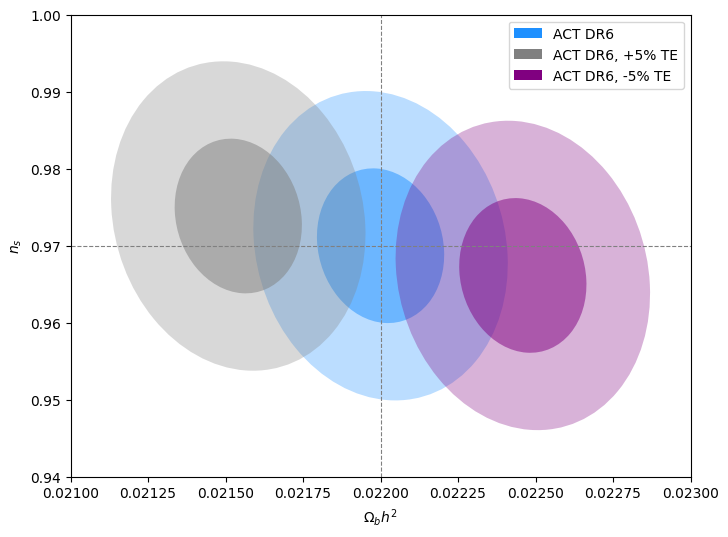

In [50]:
fig, ax = plt.subplots(figsize=(8, 6))

i = parameters_baseline.index("ombh2")
j = parameters_baseline.index("ns")

add_ellipse(ax, (theta_baseline[i], theta_baseline[j]), (err[i], err[j]), cov[i,j], facecolor="dodgerblue", alpha=0.5)
add_ellipse(ax, (theta_baseline[i], theta_baseline[j]), (err[i], err[j]), cov[i,j], facecolor="dodgerblue", alpha=0.3, nstd=2)

add_ellipse(ax, (theta_baseline[i] + Dtheta1[i], theta_baseline[j] + Dtheta1[j]), (err[i], err[j]), cov[i,j], facecolor="grey", alpha=0.5)
add_ellipse(ax, (theta_baseline[i] + Dtheta1[i], theta_baseline[j] + Dtheta1[j]), (err[i], err[j]), cov[i,j], facecolor="grey", alpha=0.3, nstd=2)

add_ellipse(ax, (theta_baseline[i] + Dtheta2[i], theta_baseline[j] + Dtheta2[j]), (err[i], err[j]), cov[i,j], facecolor="purple", alpha=0.5)
add_ellipse(ax, (theta_baseline[i] + Dtheta2[i], theta_baseline[j] + Dtheta2[j]), (err[i], err[j]), cov[i,j], facecolor="purple", alpha=0.3, nstd=2)

ax.axvline(parameter_values["ombh2"], c="grey", lw=0.8, ls="--")
ax.axhline(parameter_values["ns"], c="grey", lw=0.8, ls="--")

ax.fill_between([], [], [], fc="dodgerblue", label="ACT DR6")
ax.fill_between([], [], [], fc="grey", label="ACT DR6, +5% TE")
ax.fill_between([], [], [], fc="purple", label="ACT DR6, -5% TE")

ax.legend(loc="best")

ax.set_xlabel(r"$\Omega_b h^2$")
ax.set_ylabel(r"$n_s$")
ax.set_xlim(0.021, 0.023)
ax.set_ylim(0.94, 1.0);

We can also do this in a continuous parameter space. The function `jax.vmap()` can quickly compute a function over a range of values - thus we can plot the trace of our bias across parameter space.

In [79]:
# Even, better, we can compute this along a continuous line quickly
te_amp = np.linspace(0.95, 1.05, 1000)

def d_theta(x):
    d = offset_model(theta_baseline, te_bias=x) - offset_model(theta_baseline, te_bias=1.0)
    return Finv @ J.T @ like.inv_cov @ d

par_bias = jax.vmap(d_theta)(te_amp)

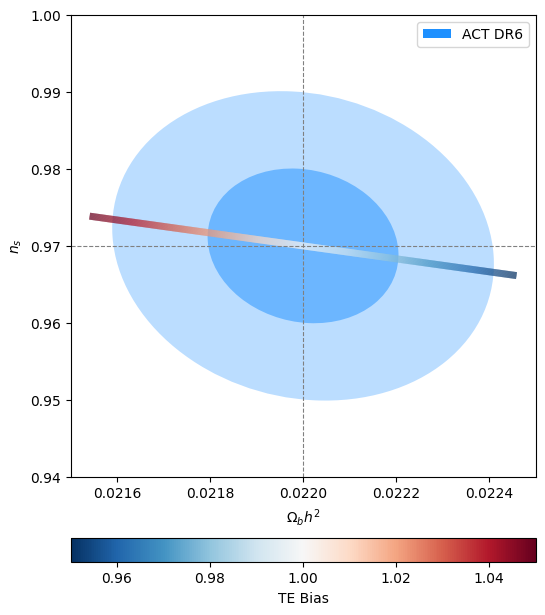

In [80]:
from matplotlib import collections as mpc, colors as mcl

fig, ax = plt.subplots(figsize=(6, 8))

add_ellipse(ax, (theta_baseline[i], theta_baseline[j]), (err[i], err[j]), cov[i,j], facecolor="dodgerblue", alpha=0.5)
add_ellipse(ax, (theta_baseline[i], theta_baseline[j]), (err[i], err[j]), cov[i,j], facecolor="dodgerblue", alpha=0.3, nstd=2)

norm = mcl.Normalize(vmin=0.95, vmax=1.05)
cmap = plt.get_cmap("RdBu_r")

points = theta_baseline[None,:] + par_bias
points = np.column_stack([points[:,i], points[:,j]])
segments = np.stack([points[:-1], points[1:]], axis=1)

lc = mpc.LineCollection(segments, cmap=cmap, norm=norm, linewidth=5)
lc.set_array((te_amp[:-1] + te_amp[1:]) / 2.)

ax.add_collection(lc)

ax.axvline(parameter_values["ombh2"], c="grey", lw=0.8, ls="--")
ax.axhline(parameter_values["ns"], c="grey", lw=0.8, ls="--")

ax.fill_between([], [], [], fc="dodgerblue", label="ACT DR6")
fig.colorbar(lc, ax=ax, orientation="horizontal", label="TE Bias", pad=0.1)

ax.legend(loc="best")

ax.set_xlabel(r"$\Omega_b h^2$")
ax.set_ylabel(r"$n_s$")
ax.set_xlim(0.0215, 0.0225)
ax.set_ylim(0.94, 1.0);